# Week 2: Updating Data Frames

## Adding a single column

In [1]:
import numpy as np
import pandas as pd

# Set seed
rng = np.random.default_rng(seed=42)

# Load data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

In [2]:
# Using dictionary-ish syntax
# df['new_col_name'] = new_column_values
# dict[new_key] = new_value

In [3]:
# Example: creating new column w/ data transformation

# Add new body_mass_kg column
penguins['body_mass_kg'] = penguins['body_mass_g']/1000

# Confirm the new column was added
print("body_mass_kg is in the data frame's columns: ", 'body_mass_kg' in penguins.columns)

# View new column
penguins.head()


body_mass_kg is in the data frame's columns:  True


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.75
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.80
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.25
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.45


In [4]:
# Using assign() method syntax - does not make change in place
# df = df.assign(new_col_name=new_column_values)

<Axes: xlabel='bill_length_cm', ylabel='body_mass_g'>

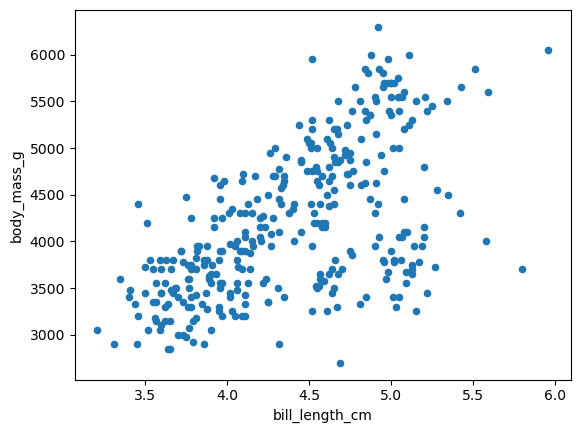

In [5]:
# Making new bill length cm column for plotting - does not change mm column
(penguins.assign(bill_length_cm=penguins['bill_length_mm']/10)
        .plot(kind='scatter',
              x='bill_length_cm', 
              y='body_mass_g')
    )

In [6]:
# Using insert() to add new column at specific location syntax
#df.insert(loc=integer_index,  # Location of new column
          #column='new_col_name', 
          #value=new_col_values)


In [7]:
# Create random 3-digit nums (id_code)
codes = rng.choice(np.arange(100, 1000), size=len(penguins), replace=False)  # Sampling w/o replacement

# Insert those at the front of data frame (id_code)
penguins.insert(loc=0,  # First position
                column='id_code',
                value=codes)
        
penguins.head()

,id_code,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg
0,630,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.75
1,679,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.80
2,175,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.25
3,330,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN
4,355,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.45


## Adding Multiple Columns

In [8]:
# Create columns with observer codes and flipper length in cm
penguins = penguins.assign(flipper_length_cm=penguins['flipper_length_mm']/10, 
                           observer=rng.choice(['A','B','C'],  # Sample with replacement
                                               size=len(penguins))
                          )
# View first 5 rows
penguins.head()

,id_code,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg,flipper_length_cm,observer
0,630,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,3.75,18.1,B
1,679,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,3.80,18.6,B
2,175,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,3.25,19.5,C
3,330,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN,NaN,C
4,355,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,3.45,19.3,C


## Removing columns

In [9]:
# Removign columns syntax
# df = df.drop(columns=col_names)

In [10]:
# Removing old unit flipper length and and body mass columns
penguins = penguins.drop(columns=['flipper_length_mm','body_mass_g'])

# Confirm result
print(penguins.columns)

Index(['id_code', 'species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'sex', 'year', 'body_mass_kg', 'flipper_length_cm', 'observer'],
      dtype='object')


## Updating values

In [16]:
# Updating a single value syntax - at[]
# df.at[single_index_value, 'column_name']

In [13]:
# Set penguins index to id_code
penguins = penguins.set_index('id_code')
penguins

,species,island,bill_length_mm,bill_depth_mm,sex,year,body_mass_kg,flipper_length_cm,observer
id_code,,,,,,,,,
630,Adelie,Torgersen,39.1,18.7,male,2007,3.750,18.1,B
679,Adelie,Torgersen,39.5,17.4,female,2007,3.800,18.6,B
175,Adelie,Torgersen,40.3,18.0,female,2007,3.250,19.5,C
330,Adelie,Torgersen,NaN,NaN,NaN,2007,NaN,NaN,C
355,Adelie,Torgersen,36.7,19.3,female,2007,3.450,19.3,C
...,...,...,...,...,...,...,...,...,...
560,Chinstrap,Dream,55.8,19.8,male,2009,4.000,20.7,A
975,Chinstrap,Dream,43.5,18.1,female,2009,3.400,20.2,A
995,Chinstrap,Dream,49.6,18.2,male,2009,3.775,19.3,B


In [14]:
# Check bill length of penguin ID 330
penguins.at[330, 'bill_length_mm']

nan

In [15]:
# Update bill length value of penguin ID 330
penguins.at[330,'bill_length_mm'] = 38.3

# Confirm update success
penguins.loc[330]

species                 Adelie
island               Torgersen
bill_length_mm            38.3
bill_depth_mm              NaN
sex                        NaN
year                      2007
body_mass_kg               NaN
flipper_length_cm          NaN
observer                     C
Name: 330, dtype: object

In [18]:
# Updating a single value syntax - iat[]
# df.iat[index_integer_location, column_integer_location]

# Find location of specific column
# df.columns.get_loc('column_name')

## Check-In

a. Obtain the location of the bill_length_mm column.

b. Use iat[] to access the same bill length value for the penguin with ID 330 and set it back to NA. Confirm your update using iloc[].

HINT: What would be an equivalent method to penguins.columns.get_loc('column_name') to get the location of a specific label in the index?

In [41]:
# Find location of bill_length_mm column
col_loc = penguins.columns.get_loc("bill_length_mm")
#Find location of index 330
ind_loc = penguins.index.get_loc(330)

In [45]:
# Find value at penguin ID 330 and bill_length_mm column loc
# df.iat[index_integer_location, column_integer_location]
penguins.iat[ind_loc,col_loc]

# Update that value to NA (again)
penguins.iat[ind_loc,col_loc] = "NaN"

In [47]:
# Confirm update success
penguins.iloc[ind_loc]

species                 Adelie
island               Torgersen
bill_length_mm             NaN
bill_depth_mm              NaN
sex                        NaN
year                      2007
body_mass_kg               NaN
flipper_length_cm          NaN
observer                     C
Name: 330, dtype: object

In [51]:
# Updating multiple values - condition or selection

# Condition Method

# Create a list with the conditions
conditions = [penguins['body_mass_kg'] < 3, 
              (3 <= penguins['body_mass_kg']) & (penguins['body_mass_kg'] < 5),
              5 <= penguins['body_mass_kg']]

# Create a list with the choices
choices = ["small",
           "medium",
           "large"]

# Add the selections using np.select
penguins['size'] = np.select(conditions, 
                             choices, 
                             default=None) # Value for anything outside conditions

# Display the updated data frame to confirm the new column
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,sex,year,body_mass_kg,flipper_length_cm,observer,size
id_code,,,,,,,,,,
630,Adelie,Torgersen,39.1,18.7,M,2007,3.75,18.1,B,medium
679,Adelie,Torgersen,39.5,17.4,female,2007,3.80,18.6,B,medium
175,Adelie,Torgersen,40.3,18.0,female,2007,3.25,19.5,C,medium
330,Adelie,Torgersen,NaN,NaN,NaN,2007,NaN,NaN,C,None
355,Adelie,Torgersen,36.7,19.3,female,2007,3.45,19.3,C,medium


In [49]:
# Syntax for selection method:
# df.loc[row_selection, column_name] = new_values

In [52]:
# Selection Method

# Select rows with sex=male and simplify values in 'sex' column
penguins.loc[penguins['sex']=='male', 'sex'] = 'M'

# Check changes in 'sex' column specifically
print(penguins['sex'].unique())

['M' 'female' nan]


In [53]:
# Best Practices

# Select rows where 'sex' is 'female' and then attempt to update 'sex' column values
# penguins[penguins['sex']=='female']['sex'] = 'F' # This raises SettingWithCopyWarning

# Confirm values were updated
# print(penguins['sex'].unique())

## Check-In

1. Update the “female” values in the penguins data frame to “F”. Don’t use chained indexing. Confirm that the values in the column were updated.

In [57]:
# Select rows with sex=male and simplify values in 'sex' column
penguins.loc[penguins['sex']=='female', 'sex'] = 'F'
# Confirm update success
print(penguins['sex'].unique())

['M' 'F' nan]


In [58]:
# Example

# Select penguins from Biscoe island
biscoe = penguins[penguins['island']=='Biscoe']

# ... Other analyses ...

# Add a column
# biscoe['sample_col'] = 100  # This raises SettingWithCopyWarning

In [60]:
# Avoid warning by creating df copy
biscoe = penguins[penguins['island']=='Biscoe'].copy()

# Add a column, no warning
biscoe['sample_col'] = 100

In [62]:
# Confirm copy exists and new column was added
biscoe.head()

,species,island,bill_length_mm,bill_depth_mm,sex,year,body_mass_kg,flipper_length_cm,observer,size,sample_col
id_code,,,,,,,,,,,
954,Adelie,Biscoe,37.8,18.3,F,2007,3.40,17.4,B,medium,100
503,Adelie,Biscoe,37.7,18.7,M,2007,3.60,18.0,B,medium,100
567,Adelie,Biscoe,35.9,19.2,F,2007,3.80,18.9,B,medium,100
827,Adelie,Biscoe,38.2,18.1,M,2007,3.95,18.5,C,medium,100
438,Adelie,Biscoe,38.8,17.2,M,2007,3.80,18.0,B,medium,100


In [63]:
# Confirm original df not modified
print('sample_col' in penguins.columns)

False


## Lesson Summary:

Methods to *add columns* to pandas.DataFrame:
- Dictionary Syntax:
    - `df['new_col_name'] = new_column_values`
- Assign Syntax:
    - `df = df.assign(new_col_name=new_column_values)`
    - `df = df.assign(new_col1_name=new_col1_values, new_col2_name=new_col2_values)`
- Insert Syntax:
    - `df.insert(loc=integer_index, column='new_col_name', value=new_col_values)`
 
Method to *remove columns* from pandas.DataFrame:
- Drop Syntax:
    - `df = df.drop(columns=col_names)`

Methods to *update columns* in pandas.DataFrame: (use `.copy()` for updating in a subset)
- at[] Syntax:
    - `df.at[single_index_value, 'column_name']`
- iat[] Syntax:
    - `df.iat[index_integer_location, column_integer_location]`
- .loc[] Syntax:
    - `df.loc[row_selection, column_name] = new_values`
- np.select() Syntax:
    - `df[column_selection] = np.select(conditions, choices, default=None)`
